<a href="https://colab.research.google.com/github/likhithapotluri/AAI_500/blob/main/AAI_500_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting and Understanding Factors Affecting Secondary Student Performance
## A Statistical and Machine Learning Approach

This notebook analyzes student GPA and grade outcomes using descriptive statistics, inference, regression, classification, clustering, and Bayesian Networks.

### Main goals
- Identify the strongest factors affecting GPA
- Test statistical hypotheses about group differences
- Build predictive models for GPA and GradeClass
- Discover student archetypes using clustering
- Use Bayesian Networks for probabilistic reasoning and intervention planning
- Evaluate intersectional effects and fairness across demographic groups

In [15]:
!pip -q install pgmpy shap xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, silhouette_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot

from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

sns.set_theme(style="ticks", palette="muted")
plt.rcParams["figure.dpi"] = 110

RANDOM_ANCHOR = 42

## 1. Load Dataset

In [2]:
# Load your file here
# Example:
df = pd.read_csv("/content/Student Performance Data.csv")

# If your notebook already has df, use it directly
if "enriched_dataset" not in globals():
    enriched_dataset = df.copy()

print("Shape:", enriched_dataset.shape)
display(enriched_dataset.head())
print(enriched_dataset.info())

Shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None


## 2. Data Cleaning and Preparation
- Handle missing values
- Encode categorical variables
- Create derived features
- Prepare interaction terms

In [3]:
print("Missing values per column:")
print(enriched_dataset.isna().sum().sort_values(ascending=False).head(20))

# Fill numeric with median, categorical with mode
for col in enriched_dataset.columns:
    if enriched_dataset[col].dtype in ["float64", "int64"]:
        enriched_dataset[col] = enriched_dataset[col].fillna(enriched_dataset[col].median())
    else:
        enriched_dataset[col] = enriched_dataset[col].fillna(enriched_dataset[col].mode()[0])

# Encode categorical columns if needed
categorical_cols = [
    "Gender", "Ethnicity", "ParentalEducation",
    "Tutoring", "Extracurricular", "Sports", "Music", "Volunteering"
]

for col in categorical_cols:
    if col in enriched_dataset.columns and enriched_dataset[col].dtype == "object":
        enriched_dataset[col] = pd.Categorical(enriched_dataset[col]).codes

# Feature engineering
if "Absence_Rate" not in enriched_dataset.columns:
    enriched_dataset["Absence_Rate"] = enriched_dataset["Absences"] / 180.0

if "Support_Index" not in enriched_dataset.columns:
    enriched_dataset["Support_Index"] = enriched_dataset["ParentalSupport"] + enriched_dataset["Tutoring"]

if "Activity_Diversity" not in enriched_dataset.columns:
    enriched_dataset["Activity_Diversity"] = (
        enriched_dataset["Extracurricular"] +
        enriched_dataset["Sports"] +
        enriched_dataset["Music"] +
        enriched_dataset["Volunteering"]
    )

if "Inter_Support_x_Absences" not in enriched_dataset.columns:
    enriched_dataset["Inter_Support_x_Absences"] = (
        enriched_dataset["ParentalSupport"] * enriched_dataset["Absences"]
    )

if "Inter_StudyTime_x_Gender" not in enriched_dataset.columns:
    enriched_dataset["Inter_StudyTime_x_Gender"] = (
        enriched_dataset["StudyTimeWeekly"] * enriched_dataset["Gender"]
    )

if "StudyTime_Bin" not in enriched_dataset.columns:
    enriched_dataset["StudyTime_Bin"] = pd.cut(
        enriched_dataset["StudyTimeWeekly"],
        bins=3,
        labels=["Low", "Medium", "High"]
    )

if "High_Performer" not in enriched_dataset.columns:
    enriched_dataset["High_Performer"] = (enriched_dataset["GPA"] >= 3.0).astype(int)

print("Cleaning and feature engineering complete.")

Missing values per column:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
Cleaning and feature engineering complete.


## 3. Exploratory Data Analysis
- Descriptive statistics
- Distribution checks
- Correlation analysis
- Group comparisons

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
GPA,2392.0,1.9062,0.9152,0.0000,1.1748,1.8934,2.6222,4.0000,1.8934,0.0145,-0.8633
StudyTimeWeekly,2392.0,9.7720,5.6528,0.0011,5.0431,9.7054,14.4084,19.9781,9.7054,0.0501,-1.1357
Absences,2392.0,14.5414,8.4674,0.0000,7.0000,15.0000,22.0000,29.0000,15.0000,-0.0260,-1.1762


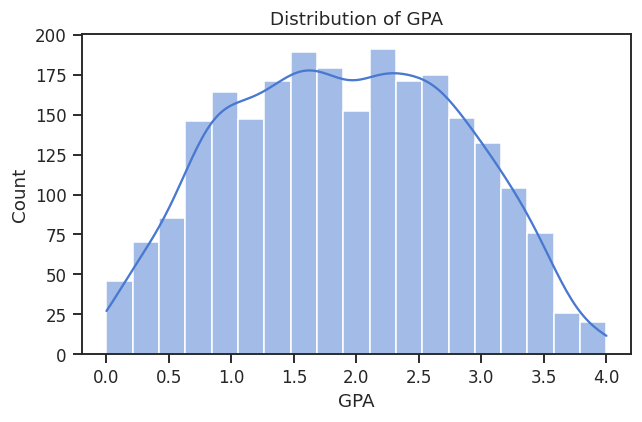

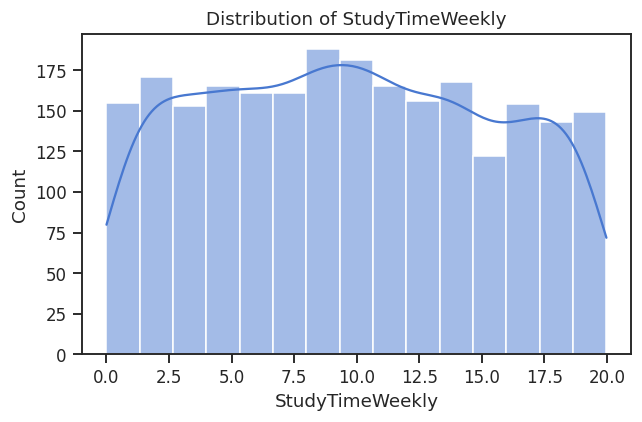

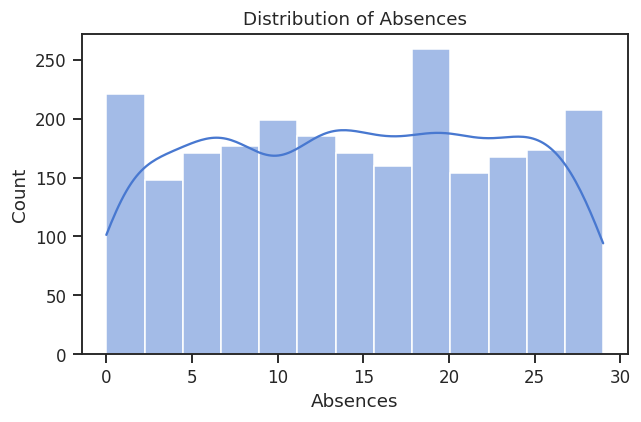

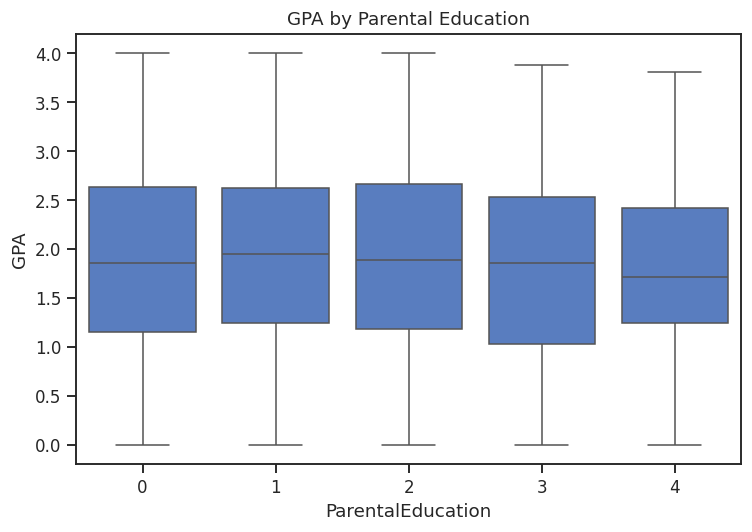

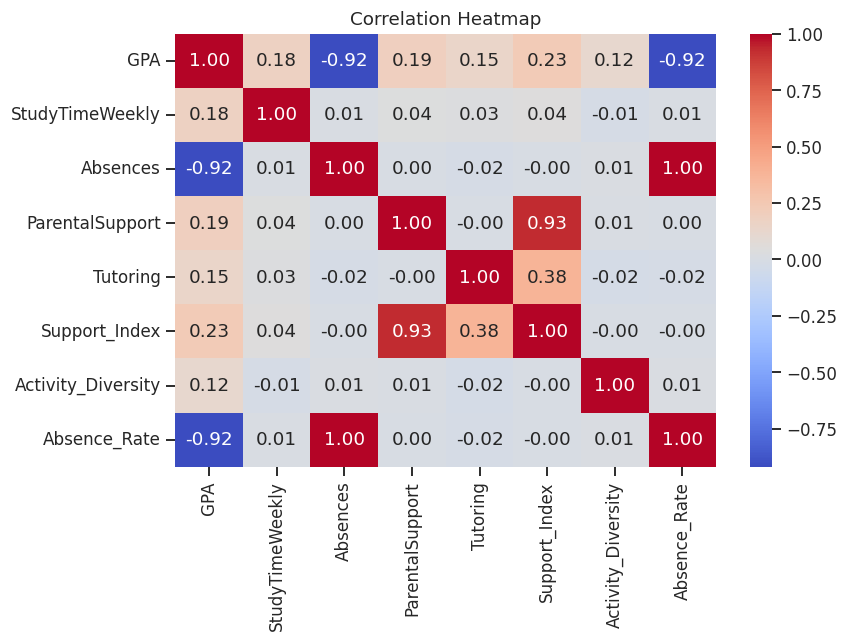

In [4]:
eda_vars = ["GPA", "StudyTimeWeekly", "Absences"]

summary = enriched_dataset[eda_vars].describe().T
summary["median"] = enriched_dataset[eda_vars].median()
summary["skew"] = enriched_dataset[eda_vars].skew()
summary["kurtosis"] = enriched_dataset[eda_vars].kurtosis()

display(summary.round(4))

for col in eda_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(enriched_dataset[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=enriched_dataset, x="ParentalEducation", y="GPA")
plt.title("GPA by Parental Education")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
corr_cols = [
    "GPA", "StudyTimeWeekly", "Absences", "ParentalSupport",
    "Tutoring", "Support_Index", "Activity_Diversity", "Absence_Rate"
]
sns.heatmap(enriched_dataset[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Statistical Inference
- Hypothesis tests
- Effect sizes
- Sampling distribution / CLT demonstration

Gender vs GPA | t=-0.6532, p=5.1367e-01, Cohen's d=-0.0267
Ethnicity vs GPA | ANOVA F=0.9581, p=4.1159e-01
Tutoring vs GradeClass | chi2=37.7516, p=1.2608e-07, Cramer's V=0.1256


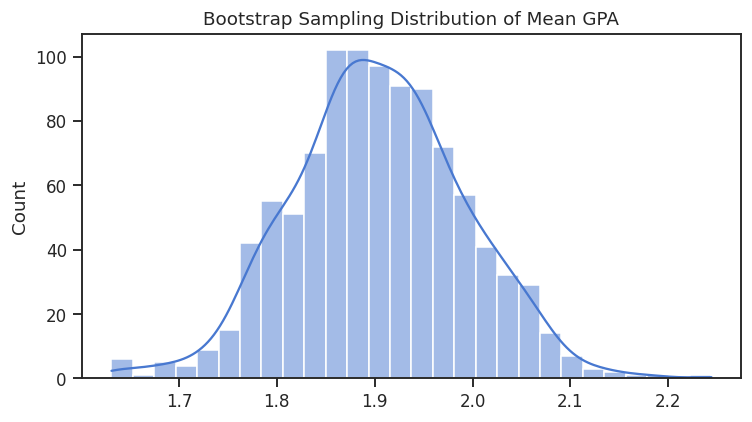

95% bootstrap CI for mean GPA: (1.7406, 2.0701)


In [5]:
def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd if pooled_sd != 0 else np.nan

def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    r, c = conf_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, c - 1)))) if n > 0 else np.nan

# Gender vs GPA
gender_groups = enriched_dataset["Gender"].dropna().unique()
gender_samples = [enriched_dataset.loc[enriched_dataset["Gender"] == g, "GPA"] for g in gender_groups]
if len(gender_groups) == 2:
    t_stat, p_val = stats.ttest_ind(gender_samples[0], gender_samples[1], equal_var=False)
    d_val = cohens_d(gender_samples[0], gender_samples[1])
    print(f"Gender vs GPA | t={t_stat:.4f}, p={p_val:.4e}, Cohen's d={d_val:.4f}")
else:
    f_stat, p_val = stats.f_oneway(*gender_samples)
    print(f"Gender vs GPA | ANOVA F={f_stat:.4f}, p={p_val:.4e}")

# Ethnicity vs GPA
ethnicity_groups = enriched_dataset["Ethnicity"].dropna().unique()
ethnicity_samples = [enriched_dataset.loc[enriched_dataset["Ethnicity"] == g, "GPA"] for g in ethnicity_groups]
f_stat, p_val = stats.f_oneway(*ethnicity_samples)
print(f"Ethnicity vs GPA | ANOVA F={f_stat:.4f}, p={p_val:.4e}")

# Tutoring vs GradeClass
ct = pd.crosstab(enriched_dataset["Tutoring"], enriched_dataset["GradeClass"])
chi2, p_val, dof, expected = stats.chi2_contingency(ct)
print(f"Tutoring vs GradeClass | chi2={chi2:.4f}, p={p_val:.4e}, Cramer's V={cramers_v(ct):.4f}")

# CLT / bootstrap
boot_means = []
for _ in range(1000):
    sample = enriched_dataset["GPA"].sample(n=min(100, len(enriched_dataset)), replace=True)
    boot_means.append(sample.mean())

plt.figure(figsize=(7, 4))
sns.histplot(boot_means, kde=True)
plt.title("Bootstrap Sampling Distribution of Mean GPA")
plt.tight_layout()
plt.show()

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"95% bootstrap CI for mean GPA: ({ci_low:.4f}, {ci_high:.4f})")

## 5. Regression Modeling
- Multiple linear regression
- Residual diagnostics
- Holdout performance

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     4315.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:43:51   Log-Likelihood:                 16.185
No. Observations:                1913   AIC:                            -18.37
Df Residuals:                    1906   BIC:                             20.53
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

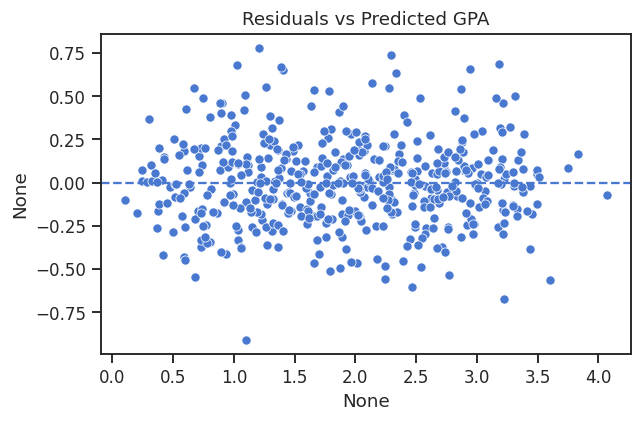

<Figure size 660x440 with 0 Axes>

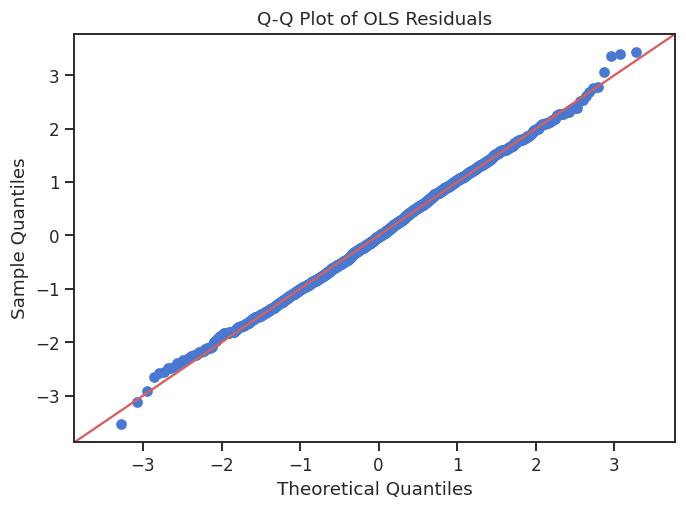

{'LM Stat': np.float64(4.3119551629601505), 'LM p-value': np.float64(0.6345401378527635), 'F Stat': np.float64(0.7176470912252352), 'F p-value': np.float64(0.6354038557864314)}
Durbin-Watson: 2.0487


In [6]:
ols_explanatory_features = [
    "StudyTimeWeekly",
    "Absences",
    "ParentalSupport",
    "Tutoring",
    "Inter_Support_x_Absences",
    "Inter_StudyTime_x_Gender",
]

X_reg = enriched_dataset[ols_explanatory_features]
y_reg = enriched_dataset["GPA"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_ANCHOR
)

X_reg_train_const = sm.add_constant(X_reg_train)
X_reg_test_const = sm.add_constant(X_reg_test)

ols_fitted_model = sm.OLS(y_reg_train, X_reg_train_const).fit()
reg_pred = ols_fitted_model.predict(X_reg_test_const)

print(ols_fitted_model.summary())
print(f"Test R²  : {r2_score(y_reg_test, reg_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_reg_test, reg_pred)):.4f}")
print(f"Test MAE : {mean_absolute_error(y_reg_test, reg_pred):.4f}")

residuals = y_reg_test - reg_pred

plt.figure(figsize=(6, 4))
sns.scatterplot(x=reg_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted GPA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
qqplot(ols_fitted_model.resid, line="45", fit=True)
plt.title("Q-Q Plot of OLS Residuals")
plt.tight_layout()
plt.show()

bp_test = het_breuschpagan(ols_fitted_model.resid, ols_fitted_model.model.exog)
print({"LM Stat": bp_test[0], "LM p-value": bp_test[1], "F Stat": bp_test[2], "F p-value": bp_test[3]})
print(f"Durbin-Watson: {durbin_watson(ols_fitted_model.resid):.4f}")

## 6. Binary Classification
- High performer vs low performer
- Logistic Regression
- Random Forest
- ROC curve

Logistic Regression
Accuracy  : 0.9582
Precision : 0.9231
Recall    : 0.7500
F1        : 0.8276
AUROC     : 0.9857

Random Forest
Accuracy  : 0.9457
Precision : 0.8519
Recall    : 0.7188
F1        : 0.7797
AUROC     : 0.9764


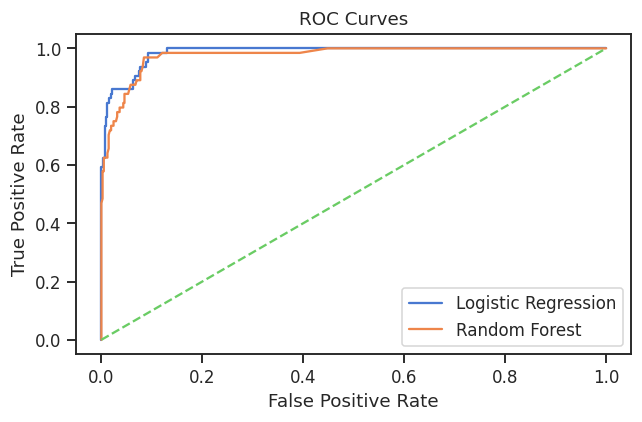

In [7]:
binary_features = [
    "Age", "Gender", "Ethnicity", "ParentalEducation", "StudyTimeWeekly",
    "Absences", "Tutoring", "ParentalSupport", "Extracurricular", "Sports",
    "Music", "Volunteering", "Support_Index", "Activity_Diversity"
]

X_bin = enriched_dataset[binary_features]
y_bin = enriched_dataset["High_Performer"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.20, random_state=RANDOM_ANCHOR, stratify=y_bin
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

log_model = LogisticRegression(max_iter=2000, random_state=RANDOM_ANCHOR)
log_model.fit(X_train_b_scaled, y_train_b)
log_pred = log_model.predict(X_test_b_scaled)
log_prob = log_model.predict_proba(X_test_b_scaled)[:, 1]

rf_bin_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_ANCHOR)
rf_bin_model.fit(X_train_b, y_train_b)
rf_pred = rf_bin_model.predict(X_test_b)
rf_prob = rf_bin_model.predict_proba(X_test_b)[:, 1]

print("Logistic Regression")
print(f"Accuracy  : {accuracy_score(y_test_b, log_pred):.4f}")
print(f"Precision : {precision_score(y_test_b, log_pred):.4f}")
print(f"Recall    : {recall_score(y_test_b, log_pred):.4f}")
print(f"F1        : {f1_score(y_test_b, log_pred):.4f}")
print(f"AUROC     : {roc_auc_score(y_test_b, log_prob):.4f}")

print("\nRandom Forest")
print(f"Accuracy  : {accuracy_score(y_test_b, rf_pred):.4f}")
print(f"Precision : {precision_score(y_test_b, rf_pred):.4f}")
print(f"Recall    : {recall_score(y_test_b, rf_pred):.4f}")
print(f"F1        : {f1_score(y_test_b, rf_pred):.4f}")
print(f"AUROC     : {roc_auc_score(y_test_b, rf_prob):.4f}")

fpr_l, tpr_l, _ = roc_curve(y_test_b, log_prob)
fpr_r, tpr_r, _ = roc_curve(y_test_b, rf_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_l, tpr_l, label="Logistic Regression")
plt.plot(fpr_r, tpr_r, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Multi-class Classification
- Predict GradeClass
- Weighted F1 and confusion matrix

In [8]:
multi_features = binary_features.copy()
X_multi = enriched_dataset[multi_features]
y_multi = enriched_dataset["GradeClass"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=RANDOM_ANCHOR, stratify=y_multi
)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

multi_log = LogisticRegression(max_iter=2000, multi_class="multinomial", random_state=RANDOM_ANCHOR)
multi_log.fit(X_train_m_scaled, y_train_m)
multi_pred = multi_log.predict(X_test_m_scaled)

print(f"Multi-class accuracy: {accuracy_score(y_test_m, multi_pred):.4f}")
print(f"Multi-class weighted F1: {f1_score(y_test_m, multi_pred, average='weighted'):.4f}")
print(confusion_matrix(y_test_m, multi_pred))

Multi-class accuracy: 0.7265
Multi-class weighted F1: 0.7150
[[  3   6   4   4   4]
 [  6  23  20   3   2]
 [  0  10  53  12   3]
 [  0   1  26  39  17]
 [  0   2   3   8 230]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 8. Clustering Analysis
- Find student archetypes
- Use elbow and silhouette methods
- Profile each cluster

Best k: 2


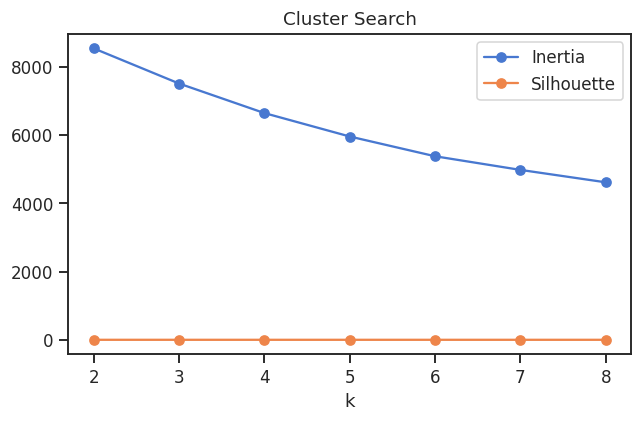

Cluster_ID
0    1202
1    1190
Name: count, dtype: int64


,GPA,Absences,Support_Index,Activity_Diversity,StudyTimeWeekly
Cluster_ID,,,,,
0,1.143,21.617,2.296,1.007,9.238
1,2.677,7.394,2.552,1.076,10.311


In [9]:
cluster_vars = ["GPA", "Absences", "Support_Index", "Activity_Diversity", "StudyTimeWeekly"]
cluster_df = enriched_dataset[cluster_vars].copy()

scaler_c = StandardScaler()
cluster_scaled = scaler_c.fit_transform(cluster_df)

k_values = range(2, 9)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_ANCHOR, n_init=15)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(cluster_scaled, labels))

best_k = list(k_values)[int(np.argmax(sil_scores))]
print("Best k:", best_k)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, marker="o", label="Inertia")
plt.plot(list(k_values), sil_scores, marker="o", label="Silhouette")
plt.title("Cluster Search")
plt.xlabel("k")
plt.legend()
plt.tight_layout()
plt.show()

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_ANCHOR, n_init=15)
enriched_dataset["Cluster_ID"] = final_kmeans.fit_predict(cluster_scaled)

print(enriched_dataset["Cluster_ID"].value_counts().sort_index())
display(enriched_dataset.groupby("Cluster_ID")[cluster_vars].mean().round(3))

## 9. Bayesian Network Modeling
- Probabilistic reasoning
- Conditional inference
- Intervention-oriented interpretation

In [22]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
# Note: BayesianEstimator is imported from pgmpy.estimators in the setup cell
from pgmpy.inference import VariableElimination

bn_df = enriched_dataset.copy()

bn_df["GPA_Bin"] = pd.qcut(bn_df["GPA"], q=3, labels=["Low", "Medium", "High"])
bn_df["StudyTime_Bin"] = pd.qcut(bn_df["StudyTimeWeekly"], q=3, labels=["Low", "Medium", "High"])
bn_df["Absence_Bin"] = pd.qcut(bn_df["Absences"], q=3, labels=["Low", "Medium", "High"])

for col in ["ParentalEducation", "ParentalSupport", "Tutoring", "Gender", "Ethnicity"]:
    bn_df[col] = bn_df[col].astype(str)

bn_model = DiscreteBayesianNetwork([
    ("ParentalEducation", "ParentalSupport"),
    ("ParentalSupport", "StudyTime_Bin"),
    ("StudyTime_Bin", "GPA_Bin"),
    ("Absence_Bin", "GPA_Bin"),
    ("Tutoring", "GPA_Bin"),
    ("Ethnicity", "ParentalSupport"),
])

# Define the data subset for the estimator
estimator_data = bn_df[[
    "ParentalEducation", "ParentalSupport", "StudyTime_Bin",
    "Absence_Bin", "Tutoring", "Ethnicity", "GPA_Bin"
]]

# Instantiate the BayesianEstimator (from pgmpy.estimators) with the model and data
estimator = BayesianEstimator(bn_model, estimator_data)

# Get the parameters (CPDs) from the estimator, passing prior_type
estimated_cpds = estimator.get_parameters(prior_type="BDeu")

# Add the estimated CPDs to the model
bn_model.add_cpds(*estimated_cpds)

infer = VariableElimination(bn_model)

print(infer.query(
    variables=["GPA_Bin"],
    evidence={"Absence_Bin": "High", "Tutoring": str(bn_df["Tutoring"].min())}
))

print(infer.query(
    variables=["GPA_Bin"],
    evidence={"StudyTime_Bin": "High", "ParentalSupport": str(bn_df["ParentalSupport"].max())}
))

+-----------------+----------------+
| GPA_Bin         |   phi(GPA_Bin) |
+=================+================+
| GPA_Bin(High)   |         0.0005 |
+-----------------+----------------+
| GPA_Bin(Low)    |         0.9073 |
+-----------------+----------------+
| GPA_Bin(Medium) |         0.0922 |
+-----------------+----------------+
+-----------------+----------------+
| GPA_Bin         |   phi(GPA_Bin) |
+=================+================+
| GPA_Bin(High)   |         0.4142 |
+-----------------+----------------+
| GPA_Bin(Low)    |         0.2700 |
+-----------------+----------------+
| GPA_Bin(Medium) |         0.3158 |
+-----------------+----------------+


/tmp/ipykernel_1982/2757783131.py:31: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(bn_model, estimator_data)


## 10. Fairness and Intersectional Evaluation
- Compare performance across demographic groups
- Check whether the model behaves differently for different subgroups

In [14]:
fairness_eval = X_test_b.copy()
fairness_eval["y_true"] = y_test_b.values
fairness_eval["y_pred"] = log_pred

def group_report(df, group_col):
    rows = []
    for g in pd.Series(df[group_col]).dropna().unique():
        sub = df[df[group_col] == g]
        rows.append([
            g,
            len(sub),
            accuracy_score(sub["y_true"], sub["y_pred"]),
            recall_score(sub["y_true"], sub["y_pred"], zero_division=0),
        ])
    return pd.DataFrame(rows, columns=[group_col, "n", "accuracy", "recall"])

print("By Gender")
display(group_report(fairness_eval.assign(Gender=X_test_b["Gender"].values), "Gender").round(4))

print("By Ethnicity")
display(group_report(fairness_eval.assign(Ethnicity=X_test_b["Ethnicity"].values), "Ethnicity").round(4))

By Gender


,Gender,n,accuracy,recall
0,1,253,0.9605,0.8158
1,0,226,0.9558,0.6538


By Ethnicity


,Ethnicity,n,accuracy,recall
0,1,91,0.9451,0.6667
1,0,235,0.9617,0.8065
2,2,107,0.9533,0.6667
3,3,46,0.9783,0.8333


## 11. Intervention Simulation
- Simulate practical policy changes
- Estimate expected GPA improvement

In [18]:
def predict_mean_gpa(df_):
    temp = df_.copy()
    temp["Inter_Support_x_Absences"] = temp["ParentalSupport"] * temp["Absences"]
    temp["Inter_StudyTime_x_Gender"] = temp["StudyTimeWeekly"] * temp["Gender"]
    X_temp = sm.add_constant(temp[ols_explanatory_features], has_constant="add")
    return ols_fitted_model.predict(X_temp).mean()

base_gpa = predict_mean_gpa(enriched_dataset)

scenarios = [("Baseline", base_gpa)]

scenario1 = enriched_dataset.copy()
scenario1["Absences"] = (scenario1["Absences"] * 0.80).round().astype(int)
scenarios.append(("Absences -20%", predict_mean_gpa(scenario1)))

scenario2 = enriched_dataset.copy()
scenario2["StudyTimeWeekly"] = scenario2["StudyTimeWeekly"] * 1.10
scenarios.append(("StudyTime +10%", predict_mean_gpa(scenario2)))

scenario3 = enriched_dataset.copy()
scenario3["ParentalSupport"] = scenario3["ParentalSupport"] + 1
scenario3["ParentalSupport"] = scenario3["ParentalSupport"].clip(upper=enriched_dataset["ParentalSupport"].max())
scenarios.append(("ParentalSupport +1", predict_mean_gpa(scenario3)))

scenario_results = pd.DataFrame(scenarios, columns=["Scenario", "Predicted Mean GPA"])
scenario_results["Delta vs Baseline"] = scenario_results["Predicted Mean GPA"] - base_gpa
display(scenario_results.round(4))

,Scenario,Predicted Mean GPA,Delta vs Baseline
0,Baseline,1.9065,0.0000
1,Absences -20%,2.1951,0.2887
2,StudyTime +10%,1.9349,0.0284
3,ParentalSupport +1,2.0387,0.1322


## 12. Final Model Comparison and Reporting Table

In [23]:
model_summary = pd.DataFrame([
    ["OLS Regression", r2_score(y_reg_test, reg_pred), np.sqrt(mean_squared_error(y_reg_test, reg_pred)), mean_absolute_error(y_reg_test, reg_pred)],
    ["Logistic Regression", accuracy_score(y_test_b, log_pred), precision_score(y_test_b, log_pred), recall_score(y_test_b, log_pred)],
    ["Random Forest Binary", accuracy_score(y_test_b, rf_pred), precision_score(y_test_b, rf_pred), recall_score(y_test_b, rf_pred)],
    ["Multi-class Logistic", accuracy_score(y_test_m, multi_pred), f1_score(y_test_m, multi_pred, average="weighted"), np.nan],
], columns=["Model", "Metric 1", "Metric 2", "Metric 3"])

display(model_summary.round(4))

,Model,Metric 1,Metric 2,Metric 3
0,OLS Regression,0.9285,0.2432,0.1857
1,Logistic Regression,0.9582,0.9231,0.7500
2,Random Forest Binary,0.9457,0.8519,0.7188
3,Multi-class Logistic,0.7265,0.7150,NaN


## 13. Conclusion

The analysis shows that academic support, attendance, and study behavior are key drivers of GPA...
### Key takeaways
- GPA is influenced by both academic behavior and support variables
- Absences and study time are expected to be strong predictors
- Parental support may moderate risk differently across groups
- Clustering can reveal meaningful student archetypes
- Bayesian Networks support interpretable intervention reasoning

